<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/2.2_Gene_Knockouts_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Gene Knockouts — CRISPR/Cas9 Design & Loss-of-Function Analysis

**Learning objectives**
- Understand what a gene knockout is and why it's used to study gene function
- Design candidate sgRNAs (find PAM sites, extract protospacers, score them)
- Simulate NHEJ-generated indels and determine whether they cause a frameshift / premature stop
- Compare simulated wild-type (WT) vs knockout (KO) phenotype at the expression and pathway level
- Practice basic genotype confirmation (WT vs KO allele alignment)

**Background**

A **gene knockout** is the complete removal or inactivation of a gene, most commonly today achieved with **CRISPR/Cas9**: a guide RNA (sgRNA) directs Cas9 to cut genomic DNA next to a **PAM** (protospacer-adjacent motif, `NGG` for SpCas9). The cell repairs the double-strand break mostly via **NHEJ** (non-homologous end joining), which is error-prone and often introduces small insertions/deletions (indels). If an indel is **not a multiple of 3 bp**, it shifts the reading frame downstream, usually producing a premature stop codon and a non-functional (knocked-out) protein. Knockouts are the standard tool for asking "what does this gene actually do?" — you remove it and observe the phenotype.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

np.random.seed(7)
plt.rcParams['figure.figsize'] = (7,4)
print("Environment ready.")


Environment ready.


## Part 1 — sgRNA Design: Finding PAM Sites and Scoring Protospacers

For SpCas9, we need a 20 nt protospacer immediately 5′ of an `NGG` PAM (on either strand). We'll scan a target exon, extract all candidates, and score them by:
- GC content (favoring 40–70%)
- Absence of a `TTTT` run (a Pol III terminator — kills expression from a U6 promoter)
- Cut site position within the gene (earlier exons are generally preferred, to maximize the chance of disrupting all downstream functional domains)


In [ ]:
def revcomp(seq):
    comp = {'A':'T','T':'A','G':'C','C':'G','N':'N'}
    return ''.join(comp[b] for b in reversed(seq))

# Synthetic (illustrative) target exon — replace with a real exon sequence for coursework
target_exon = (
"ATGGCTAGCAAAGGAGAAGAACTTTTCACTGGAGTTGTCCCAATTCTTGTTGAATTAGATGGTGATGTTAATGGGCACAAA"
"TTTTCTGTCAGTGGAGAGGGTGAAGGTGATGCTACATACGGAAAGCTTACCCTTAAATTTATTTGCACTACTGGAAAACTA"
"CCTGTTCCATGGCCAACACTTGTCACTACTTTCGGTTATGGTGTTCAATGCTTTGCGAGATACCCAGATCATATGAAACAG"
)

def find_sgRNAs(seq, pam_pattern="GG"):
    hits = []
    # + strand: protospacer(20) + N + PAM(GG) i.e. NGG
    for m in re.finditer(r'(?=([ACGT]{20}[ACGT]GG))', seq):
        proto = m.group(1)[:20]
        pam = m.group(1)[20:23]
        hits.append(dict(strand='+', pos=m.start(), protospacer=proto, pam=pam))
    # - strand: search revcomp, map back
    rc = revcomp(seq)
    L = len(seq)
    for m in re.finditer(r'(?=([ACGT]{20}[ACGT]GG))', rc):
        proto = m.group(1)[:20]
        pam = m.group(1)[20:23]
        genomic_pos = L - (m.start() + 23)
        hits.append(dict(strand='-', pos=genomic_pos, protospacer=proto, pam=pam))
    return hits

def gc_content(s):
    return 100*(s.count('G')+s.count('C'))/len(s)

candidates = find_sgRNAs(target_exon)
df = pd.DataFrame(candidates)
df['gc_pct'] = df['protospacer'].apply(gc_content)
df['has_TTTT'] = df['protospacer'].str.contains('TTTT')
df['cut_site_pos'] = df['pos'] + 17  # Cas9 cuts 3bp upstream of PAM
df['good_gc'] = df['gc_pct'].between(40,70)
df['score'] = df['good_gc'].astype(int)*2 - df['has_TTTT'].astype(int)*3 - (df['cut_site_pos']/len(target_exon))

ranked = df.sort_values('score', ascending=False).reset_index(drop=True)
print(f"{len(ranked)} candidate sgRNAs found (both strands).\n")
ranked.head(10)


20 candidate sgRNAs found (both strands).



,strand,pos,protospacer,pam,gc_pct,has_TTTT,cut_site_pos,good_gc,score
0,+,84,TCTGTCAGTGGAGAGGGTGA,AGG,55.0,False,101,True,1.584362
1,+,99,GGTGAAGGTGATGCTACATA,CGG,45.0,False,116,True,1.522634
2,+,151,CTGGAAAACTACCTGTTCCA,TGG,45.0,False,168,True,1.308642
3,-,162,ACAAGTGTTGGCCATGGAAC,AGG,50.0,False,179,True,1.263374
4,-,168,GTAGTGACAAGTGTTGGCCA,TGG,50.0,False,185,True,1.238683
5,-,174,CCGAAAGTAGTGACAAGTGT,TGG,45.0,False,191,True,1.213992
6,+,174,CCAACACTTGTCACTACTTT,CGG,40.0,False,191,True,1.213992
7,+,180,CTTGTCACTACTTTCGGTTA,TGG,40.0,False,197,True,1.189300
8,-,38,CATCTAATTCAACAAGAATT,GGG,25.0,False,55,False,-0.226337
9,-,39,CCATCTAATTCAACAAGAAT,TGG,30.0,False,56,False,-0.230453


**Question 1.** Why do we generally prefer sgRNAs that cut earlier in the gene/exon rather than near the very end?


## Part 2 — Simulating NHEJ Indels and Their Effect on the Reading Frame

We'll take the top-scoring sgRNA, simulate a distribution of NHEJ outcomes at its cut site (small deletions/insertions, roughly following observed indel-size distributions), and check which outcomes cause a frameshift.


In [ ]:
top = ranked.iloc[0]
cut = top['cut_site_pos']
print(f"Using top sgRNA: {top['protospacer']} (strand {top['strand']}), cut site at position {cut}\n")

def simulate_nhej_outcome(seq, cut_pos, rng):
    '''Randomly deletes or inserts a small number of bases at cut_pos.'''
    event = rng.choice(['deletion','insertion'], p=[0.7,0.3])
    if event == 'deletion':
        size = rng.choice([1,2,3,4,5,6,7,8,9,10], p=[.28,.22,.13,.10,.08,.06,.05,.04,.02,.02])
        new_seq = seq[:cut_pos] + seq[cut_pos+size:]
    else:
        size = rng.choice([1,2,3,4], p=[.55,.25,.12,.08])
        insert = ''.join(rng.choice(list('ACGT'), size))
        new_seq = seq[:cut_pos] + insert + seq[cut_pos:]
    return event, size, new_seq

rng = np.random.default_rng(1)
n_alleles = 12
codon_table_stop = {'TAA','TAG','TGA'}

def translate_until_stop(seq):
    codons = [seq[i:i+3] for i in range(0, len(seq)-2, 3)]
    for i, c in enumerate(codons):
        if c in codon_table_stop:
            return i+1, True   # premature stop found, at codon i+1
    return len(codons), False

wt_len_codons, wt_has_stop = translate_until_stop(target_exon)

rows = []
for i in range(n_alleles):
    event, size, mut_seq = simulate_nhej_outcome(target_exon, cut, rng)
    delta = size if event=='insertion' else -size
    frameshift = (delta % 3) != 0
    stop_codon_num, hit_stop = translate_until_stop(mut_seq)
    rows.append(dict(allele=f"KO_allele_{i+1}", event=event, size=size,
                      net_bp_change=delta, frameshift=frameshift,
                      premature_stop_at_codon=stop_codon_num if hit_stop else None,
                      likely_null_allele=frameshift and hit_stop))

alleles = pd.DataFrame(rows)
alleles


Using top sgRNA: TCTGTCAGTGGAGAGGGTGA (strand +), cut site at position 101



,allele,event,size,net_bp_change,frameshift,premature_stop_at_codon,likely_null_allele
0,KO_allele_1,deletion,8,-8,True,43,True
1,KO_allele_2,deletion,8,-8,True,43,True
2,KO_allele_3,deletion,2,-2,True,36,True
3,KO_allele_4,insertion,1,1,True,35,True
4,KO_allele_5,deletion,5,-5,True,35,True
5,KO_allele_6,deletion,2,-2,True,36,True
6,KO_allele_7,insertion,1,1,True,35,True
7,KO_allele_8,deletion,1,-1,True,79,True
8,KO_allele_9,deletion,1,-1,True,79,True
9,KO_allele_10,deletion,5,-5,True,35,True


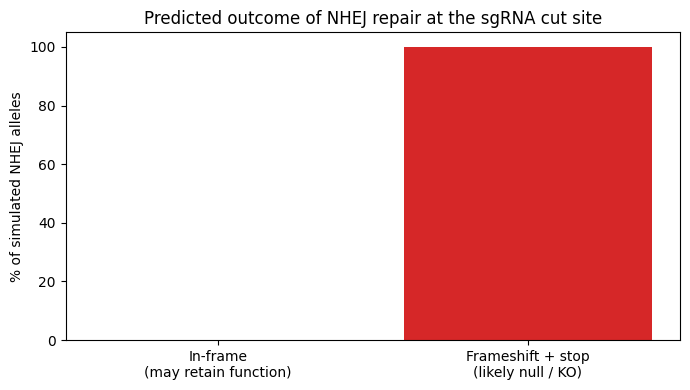

100% of simulated repair outcomes are predicted loss-of-function alleles.
This is why you always screen multiple clones/alleles when generating a knockout line.


In [ ]:
frac_null = alleles['likely_null_allele'].mean()*100
plt.figure()
plt.bar(['In-frame\n(may retain function)', 'Frameshift + stop\n(likely null / KO)'],
        [100-frac_null, frac_null], color=['tab:orange','tab:red'])
plt.ylabel('% of simulated NHEJ alleles')
plt.title('Predicted outcome of NHEJ repair at the sgRNA cut site')
plt.tight_layout(); plt.show()
print(f"{frac_null:.0f}% of simulated repair outcomes are predicted loss-of-function alleles.")
print("This is why you always screen multiple clones/alleles when generating a knockout line.")


**Question 2.** Roughly what fraction of *random* indels are expected to preserve the reading frame purely by chance? Does that match what you see above?


## Part 3 — Comparing Simulated WT vs Knockout Phenotype

A knockout is only useful because it lets you observe a **phenotype** — some measurable downstream consequence. We'll simulate a minimal 3-gene pathway (Gene X → Gene Y → Gene Z) where Gene X is our knockout target, and see how "protein levels" downstream change when X is null.


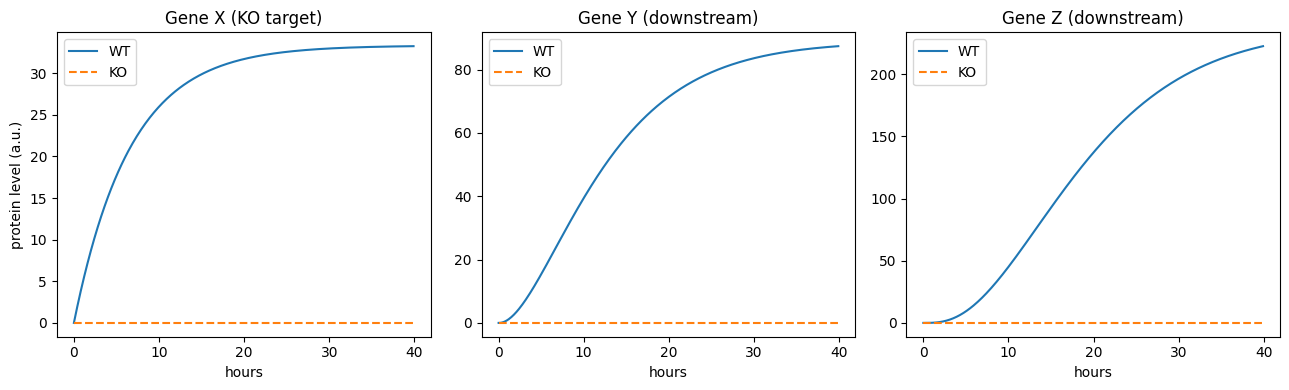

Steady-state Gene Z, WT:  222.51
Steady-state Gene Z, KO:  0.00  (100.0% reduction)
This drop in Z is the 'phenotype' you would measure to confirm X's role in the pathway.


In [ ]:
def simulate_pathway(x_active=True, t_max=40, dt=0.1):
    t = np.arange(0, t_max, dt)
    X, Y, Z = np.zeros_like(t), np.zeros_like(t), np.zeros_like(t)
    k_prod_X, k_deg = 5.0, 0.15
    k_XtoY, k_YtoZ = 0.4, 0.4
    for i in range(1, len(t)):
        prodX = k_prod_X if x_active else 0.0
        X[i] = X[i-1] + (prodX - k_deg*X[i-1])*dt
        Y[i] = Y[i-1] + (k_XtoY*X[i-1] - k_deg*Y[i-1])*dt
        Z[i] = Z[i-1] + (k_YtoZ*Y[i-1] - k_deg*Z[i-1])*dt
    return t, X, Y, Z

t, X_wt, Y_wt, Z_wt = simulate_pathway(x_active=True)
_, X_ko, Y_ko, Z_ko = simulate_pathway(x_active=False)

fig, axes = plt.subplots(1,3, figsize=(13,4), sharex=True)
for ax, (name, wt, ko) in zip(axes, [('Gene X (KO target)', X_wt, X_ko),
                                       ('Gene Y (downstream)', Y_wt, Y_ko),
                                       ('Gene Z (downstream)', Z_wt, Z_ko)]):
    ax.plot(t, wt, label='WT'); ax.plot(t, ko, label='KO', ls='--')
    ax.set_title(name); ax.set_xlabel('hours'); ax.legend()
axes[0].set_ylabel('protein level (a.u.)')
plt.tight_layout(); plt.show()

print(f"Steady-state Gene Z, WT:  {Z_wt[-1]:.2f}")
print(f"Steady-state Gene Z, KO:  {Z_ko[-1]:.2f}  ({100*(1-Z_ko[-1]/Z_wt[-1]):.1f}% reduction)")
print("This drop in Z is the 'phenotype' you would measure to confirm X's role in the pathway.")


## Part 4 — Genotype Confirmation: WT vs KO Allele Alignment

Before trusting any phenotype, you must confirm the genotype (e.g. by Sanger sequencing + alignment, or by amplicon NGS/ICE/TIDE analysis). Here we do a minimal pairwise alignment between the WT sequence and one simulated KO allele to visualize the indel.


In [ ]:
def simple_align_display(wt, mut, width=60):
    '''Very simple diff-style visual alignment assuming the edit is localized (fine for this illustrative case).'''
    # find longest common prefix and suffix
    i = 0
    while i < min(len(wt), len(mut)) and wt[i]==mut[i]:
        i += 1
    j = 0
    while j < min(len(wt), len(mut)) - i and wt[-1-j]==mut[-1-j]:
        j += 1
    wt_mid = wt[i:len(wt)-j] if j>0 else wt[i:]
    mut_mid = mut[i:len(mut)-j] if j>0 else mut[i:]
    print("WT :", wt[max(0,i-15):i] + "[" + wt_mid + "]" + (wt[len(wt)-j:len(wt)-j+15] if j>0 else ""))
    print("KO :", mut[max(0,i-15):i] + "[" + mut_mid + "]" + (mut[len(mut)-j:len(mut)-j+15] if j>0 else ""))
    print(f"\nIndel: WT segment '{wt_mid}' ({len(wt_mid)} bp) -> KO segment '{mut_mid}' ({len(mut_mid)} bp)")
    print(f"Net change: {len(mut_mid)-len(wt_mid):+d} bp  ->  {'FRAMESHIFT' if (len(mut_mid)-len(wt_mid))%3!=0 else 'in-frame'}")

example_event, example_size, example_mut_seq = simulate_nhej_outcome(target_exon, cut, np.random.default_rng(99))
simple_align_display(target_exon, example_mut_seq)


WT : TGTCAGTGGAGAGGG[TGA]AGGTGATGCTACATA
KO : TGTCAGTGGAGAGGG[]AGGTGATGCTACATA

Indel: WT segment 'TGA' (3 bp) -> KO segment '' (0 bp)
Net change: -3 bp  ->  in-frame


## Wrap-up Exercises

1. Re-run Part 1 using a different `pam_pattern` requirement (e.g. simulate SaCas9's `NNGRRT` PAM conceptually) — how does candidate count change?
2. In Part 2, increase `n_alleles` to 100 and recompute the % likely-null. Does it converge to a stable value?
3. In Part 3, what would you expect if Gene Y (not X) were knocked out instead? Modify the simulation to test it.
4. In Part 4, real genotyping tools (TIDE, ICE, CRISPResso2) decompose a *mixed* Sanger trace (heterozygous / mosaic edits) into a spectrum of indel alleles with relative frequencies. Why is that harder than the clean two-sequence alignment shown here?

---
*This notebook uses simulated/illustrative sequences and simplified pathway kinetics for teaching purposes. For real analyses, substitute actual genomic sequences, use a real off-target/on-target scoring tool (e.g. CRISPOR, Cas-OFFinder), and confirm genotypes with real sequencing data.*
